# GAVD: Gait Classification with LLM Classifiers

## 1.  Setup

In [1]:
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

# Configure matplotlib FIRST before any other imports
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# Verify matplotlib backend
print(f"Matplotlib backend: {matplotlib.get_backend()}")

# Enable interactive mode
plt.ion()

Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Suppress TensorFlow and MediaPipe logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import sys
import string
import contextlib
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict

# Setup paths
project_root = Path.cwd().parent.parent
video_base_path = project_root / "data" / "youtube"
data_root = project_root / "experiments" / "exp4" / "data"

sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Data root: {data_root}")
print(f"Video path: {video_base_path}")

Project root: /Users/pmui/dev/alex/alexpose
Data root: /Users/pmui/dev/alex/alexpose/experiments/exp4/data
Video path: /Users/pmui/dev/alex/alexpose/data/youtube


In [3]:
from ambient.gavd import GAVDDataLoader
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from ambient.pose.joint_angles import get_joint_angles

print("✓ Imports successful")

✓ Imports successful


### Save and Load Feature Data

Let's create functions to save and load the extracted features to avoid re-extracting them every time.

In [4]:
from ambient.utils.features_utils import save_features, load_features

# save_path = save_features(all_features, condition_counts)

# print(f"\nFeatures saved to: {save_path}")

### Load Previously Extracted Features

To load previously saved features instead of re-extracting them, uncomment and run the cell below:

In [5]:
from ambient.classification.features import GaitFeatureVector

all_features, condition_counts = load_features()
print(f"\n{'='*60}")
print(f"Total features loaded: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
     print(f"  {condition:15s}: {count:3d} samples")

✓ Features loaded successfully from: /Users/pmui/dev/alex/alexpose/experiments/exp4/extracted_features.pkl
  Saved on: 2026-01-22T19:55:05.183299
  Total features: 68
  Conditions: ['stroke', 'myopathic', 'parkinsons', 'normal', 'cerebralpalsy']

Total features loaded: 68

Condition distribution:
  cerebralpalsy  :  15 samples
  myopathic      :  20 samples
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples


In [6]:
# Split into train/test (80/20)
np.random.seed(42)
indices = np.random.permutation(len(all_features))
split_idx = int(0.8 * len(all_features))

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

train_features = [all_features[i] for i in train_indices]
test_features = [all_features[i] for i in test_indices]

print(f"Training samples: {len(train_features)}")
print(f"Test samples: {len(test_features)}")

Training samples: 54
Test samples: 14


## 2. LLM Classifier with Few-Shot Learning

LLM classifiers work differently from traditional ML classifiers:
- They use **few-shot learning** with labeled examples
- No traditional "training" - examples are stored for prompt context
- Classification uses LLM reasoning with example context
- Requires API keys (OpenAI or Google Gemini)

In [7]:
from ambient.classification.llm_classifier import (
    LLMClassifier,
    LLMClassifierConfig
)
import time
from collections import Counter

### 2.1 Configure LLM Classifier

Configure the LLM classifier with your preferred model and settings.

**Key Parameters:**
- `model_name`: LLM model to use (e.g., 'gpt-4o-mini', 'gemini-1.5-flash')
- `provider`: 'openai' or 'gemini'
- `temperature`: Controls randomness (0.0 = deterministic, 1.0 = creative)
- `enable_chain_of_thought`: Enable reasoning explanations
- `two_stage_classification`: First classify normal/abnormal, then identify condition

In [8]:
# Configure LLM classifier
# Note: Requires OPENAI_API_KEY or GOOGLE_API_KEY environment variable
llm_config = LLMClassifierConfig(
    model_name="gpt-4o-mini",           # Cost-effective OpenAI model
    provider="openai",                  # or "gemini"
    temperature=0.1,                    # Low temperature for consistency
    max_tokens=1000,                    # Maximum response length
    enable_chain_of_thought=True,       # Enable reasoning
    two_stage_classification=True,      # Normal/abnormal then condition
    confidence_threshold=0.7            # Minimum confidence
)

llm_classifier = LLMClassifier(llm_config)
print("✓ LLM classifier created")
print(f"  Model: {llm_config.model_name}")
print(f"  Provider: {llm_config.provider}")
print(f"  Temperature: {llm_config.temperature}")

2026-01-23 07:26:04.485 | INFO     | ambient.classification.prompt_manager:_load_prompts:58 - Loaded prompts from /Users/pmui/dev/alex/alexpose/config/classification_prompts.yaml
2026-01-23 07:26:04.485 | INFO     | ambient.classification.prompt_manager:__init__:41 - Prompt manager initialized
2026-01-23 07:26:04.485 | INFO     | ambient.classification.llm_classifier:__init__:161 - LLM classifier initialized with openai gpt-4o-mini


✓ LLM classifier created
  Model: gpt-4o-mini
  Provider: openai
  Temperature: 0.1


### 2.2 Train with Few-Shot Examples

For LLM classifiers, "training" means storing labeled examples that will be included in prompts.
The LLM uses these examples to understand the classification task.

In [9]:
# Train LLM classifier with few-shot examples
print("Training LLM classifier with few-shot examples...")
print(f"Using {len(train_features)} training samples\n")

llm_metrics = llm_classifier.train(
    train_features,
    validate=False,  # LLM doesn't use traditional CV
    auto_remove_invalid=True
)

# Display training results
print("\n" + "="*70)
print("LLM CLASSIFIER FEW-SHOT LEARNING RESULTS")
print("="*70)
print(f"Training Method:       {llm_metrics['training_method']}")
print(f"Number of Examples:    {llm_metrics['n_examples']}")
print(f"Invalid Removed:       {llm_metrics['n_invalid_removed']}")
print(f"Provider:              {llm_metrics['provider']}")
print(f"Model:                 {llm_metrics['model_name']}")
print(f"Classes:               {llm_metrics['classes']}")

# Display class distribution
print(f"\nClass Distribution in Examples:")
class_counts = Counter([f.condition_label for f in train_features if f.condition_label])
for cls in sorted(class_counts.keys()):
    print(f"  {cls:15s}: {class_counts[cls]:3d} examples")

print("="*70)
print("\n✓ LLM classifier trained with examples")

2026-01-23 07:26:04.491 | INFO     | ambient.classification.llm_classifier:train:260 - Training LLM classifier with 54 examples (few-shot learning)
2026-01-23 07:26:04.492 | WARNING  | ambient.classification.llm_classifier:train:273 - Skipping invalid feature cljas5esv00fn3n6lewd5xqdl: ["NaN values in features: ['left_hip_mean', 'left_knee_mean', 'left_ankle_mean', 'right_hip_mean', 'right_knee_mean', 'right_ankle_mean', 'hip_asymmetry', 'knee_asymmetry', 'ankle_asymmetry', 'left_hip_range', 'left_knee_range', 'left_ankle_range', 'right_hip_range', 'right_knee_range', 'right_ankle_range']"]
2026-01-23 07:26:04.492 | INFO     | ambient.classification.llm_classifier:train:301 - LLM classifier 'trained' with 53 examples (1 invalid removed)
2026-01-23 07:26:04.492 | INFO     | ambient.classification.llm_classifier:train:305 - Classes: ['stroke', 'normal', 'parkinsons', 'cerebralpalsy', 'myopathic']


Training LLM classifier with few-shot examples...
Using 54 training samples


LLM CLASSIFIER FEW-SHOT LEARNING RESULTS
Training Method:       few_shot_learning
Number of Examples:    53
Invalid Removed:       1
Provider:              openai
Model:                 gpt-4o-mini
Classes:               ['stroke', 'normal', 'parkinsons', 'cerebralpalsy', 'myopathic']

Class Distribution in Examples:
  cerebralpalsy  :  12 examples
  myopathic      :  15 examples
  normal         :  10 examples
  parkinsons     :   6 examples
  stroke         :  11 examples

✓ LLM classifier trained with examples


### 2.3 Evaluate on Test Set

Evaluate the LLM classifier on the test set. Note that this will make API calls for each sample,
so it may take some time and incur API costs.

In [10]:
# Evaluate LLM on test set
print(f"Evaluating LLM classifier on {len(test_features)} test samples...")
print("Note: This will make API calls and may take a few minutes.\n")

start_time = time.time()
llm_eval_metrics = llm_classifier.evaluate(test_features)
eval_time = time.time() - start_time

print("\n" + "="*70)
print("LLM CLASSIFIER TEST RESULTS")
print("="*70)
print(f"Test Accuracy:         {llm_eval_metrics['accuracy']:.3f}")
print(f"Evaluation Time:       {eval_time:.1f} seconds")
print(f"Avg Time per Sample:   {eval_time/len(test_features):.2f} seconds")
print(f"\nClassification Report:")

llm_report = llm_eval_metrics['classification_report']
for class_name in sorted(llm_eval_metrics['classes']):
    if class_name in llm_report:
        cm = llm_report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall:    {cm['recall']:.3f}")
        print(f"  F1-Score:  {cm['f1-score']:.3f}")
        print(f"  Support:   {cm['support']}")

print("="*70)

2026-01-23 07:26:04.497 | INFO     | ambient.classification.llm_classifier:evaluate:863 - Evaluating LLM classifier on 14 samples
2026-01-23 07:26:04.497 | INFO     | ambient.classification.llm_classifier:evaluate:864 - Note: This will make API calls and may take several minutes
2026-01-23 07:26:04.542 | INFO     | ambient.classification.llm_classifier:classify_gait:340 - Performing normal/abnormal classification


Evaluating LLM classifier on 14 test samples...
Note: This will make API calls and may take a few minutes.



2026-01-23 07:26:21.896 | INFO     | ambient.classification.llm_classifier:classify_gait:352 - Performing condition identification
2026-01-23 07:26:26.645 | INFO     | ambient.classification.llm_classifier:classify_gait:390 - Classification: parkinsons (confidence: 0.670)
2026-01-23 07:26:26.646 | INFO     | ambient.classification.llm_classifier:classify_gait:340 - Performing normal/abnormal classification
2026-01-23 07:26:39.735 | INFO     | ambient.classification.llm_classifier:classify_gait:352 - Performing condition identification
2026-01-23 07:26:43.971 | INFO     | ambient.classification.llm_classifier:classify_gait:390 - Classification: parkinsons (confidence: 0.670)
2026-01-23 07:26:43.972 | INFO     | ambient.classification.llm_classifier:classify_gait:340 - Performing normal/abnormal classification
2026-01-23 07:26:57.891 | INFO     | ambient.classification.llm_classifier:classify_gait:352 - Performing condition identification
2026-01-23 07:27:01.350 | INFO     | ambient.clas


LLM CLASSIFIER TEST RESULTS
Test Accuracy:         0.214
Evaluation Time:       258.9 seconds
Avg Time per Sample:   18.49 seconds

Classification Report:

cerebralpalsy:
  Precision: 0.000
  Recall:    0.000
  F1-Score:  0.000
  Support:   3.0

myopathic:
  Precision: 0.000
  Recall:    0.000
  F1-Score:  0.000
  Support:   5.0

normal:
  Precision: 0.000
  Recall:    0.000
  F1-Score:  0.000
  Support:   2.0

parkinsons:
  Precision: 0.214
  Recall:    1.000
  F1-Score:  0.353
  Support:   3.0

stroke:
  Precision: 0.000
  Recall:    0.000
  F1-Score:  0.000
  Support:   1.0


### 2.4 Visualize Results

Create visualizations to understand the LLM classifier's performance.

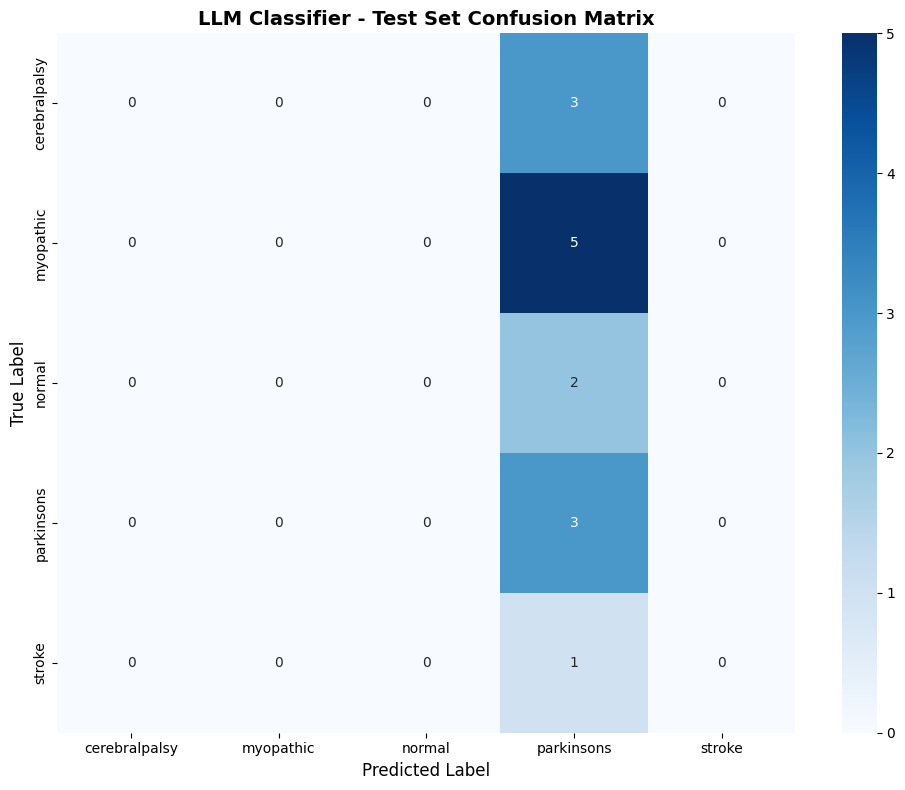


✓ Confusion matrix plotted


In [11]:
# Plot LLM confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    llm_eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(llm_eval_metrics['classes']),
    yticklabels=sorted(llm_eval_metrics['classes'])
)
plt.title('LLM Classifier - Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Confusion matrix plotted")

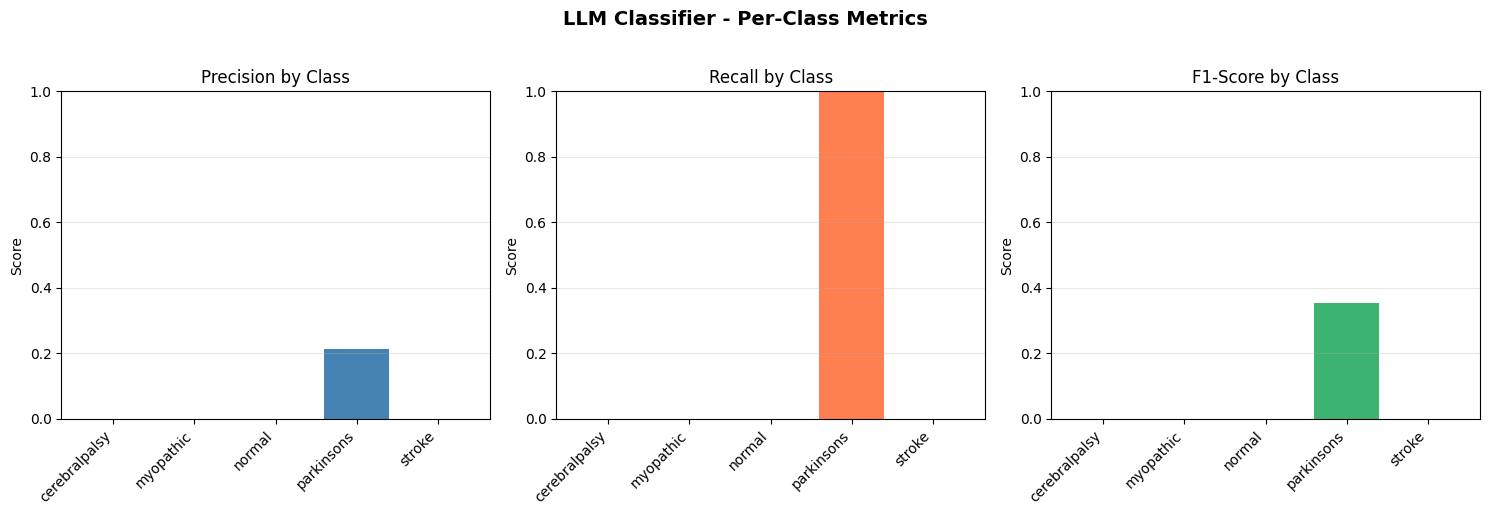


✓ Per-class metrics plotted


In [12]:
# Plot per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

classes = sorted(llm_eval_metrics['classes'])
llm_report = llm_eval_metrics['classification_report']

metrics_data = {
    'precision': [],
    'recall': [],
    'f1-score': []
}

for cls in classes:
    if cls in llm_report:
        metrics_data['precision'].append(llm_report[cls]['precision'])
        metrics_data['recall'].append(llm_report[cls]['recall'])
        metrics_data['f1-score'].append(llm_report[cls]['f1-score'])
    else:
        metrics_data['precision'].append(0)
        metrics_data['recall'].append(0)
        metrics_data['f1-score'].append(0)

# Precision
axes[0].bar(range(len(classes)), metrics_data['precision'], color='steelblue')
axes[0].set_xticks(range(len(classes)))
axes[0].set_xticklabels(classes, rotation=45, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision by Class')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Recall
axes[1].bar(range(len(classes)), metrics_data['recall'], color='coral')
axes[1].set_xticks(range(len(classes)))
axes[1].set_xticklabels(classes, rotation=45, ha='right')
axes[1].set_ylabel('Score')
axes[1].set_title('Recall by Class')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# F1-Score
axes[2].bar(range(len(classes)), metrics_data['f1-score'], color='mediumseagreen')
axes[2].set_xticks(range(len(classes)))
axes[2].set_xticklabels(classes, rotation=45, ha='right')
axes[2].set_ylabel('Score')
axes[2].set_title('F1-Score by Class')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('LLM Classifier - Per-Class Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Per-class metrics plotted")

### 2.5 Sample Predictions with Explanations

Let's examine some individual predictions to see how the LLM classifier reasons about gait patterns.

In [13]:
# Get sample predictions with explanations
print("Sample LLM Classifications with Reasoning:\n")
print("="*80)

# Select a few test samples
sample_indices = [0, 3, 7, 10] if len(test_features) > 10 else range(min(4, len(test_features)))

for idx in sample_indices:
    if idx >= len(test_features):
        break
        
    feature = test_features[idx]
    
    print(f"\nSample {idx + 1}:")
    print(f"  True Label: {feature.condition_label}")
    print(f"  Sample ID:  {feature.sample_id}")
    
    # Classify
    result = llm_classifier.classify_gait(feature)
    
    print(f"  Predicted:  {result['predicted_condition']}")
    print(f"  Confidence: {result['confidence']:.3f}")
    print(f"  Is Normal:  {result['is_normal']}")
    
    # Show explanation if available
    if 'normal_abnormal_explanation' in result:
        explanation = result['normal_abnormal_explanation']
        if len(explanation) > 200:
            explanation = explanation[:200] + "..."
        print(f"  Reasoning:  {explanation}")
    
    # Show identified conditions for abnormal cases
    if not result['is_normal'] and result.get('identified_conditions'):
        print(f"  Conditions Identified:")
        for cond in result['identified_conditions'][:2]:  # Top 2
            print(f"    - {cond.get('condition_name', 'Unknown')}: {cond.get('confidence', 0):.3f}")
    
    print("-" * 80)

print("\n✓ Sample predictions displayed")

2026-01-23 07:30:23.638 | INFO     | ambient.classification.llm_classifier:classify_gait:340 - Performing normal/abnormal classification


Sample LLM Classifications with Reasoning:


Sample 1:
  True Label: parkinsons
  Sample ID:  cljnz4y5a000k3n6lkv4b1rjn


2026-01-23 07:30:37.000 | INFO     | ambient.classification.llm_classifier:classify_gait:352 - Performing condition identification
2026-01-23 07:30:41.057 | INFO     | ambient.classification.llm_classifier:classify_gait:390 - Classification: parkinsons (confidence: 0.670)
2026-01-23 07:30:41.059 | INFO     | ambient.classification.llm_classifier:classify_gait:340 - Performing normal/abnormal classification


  Predicted:  parkinsons
  Confidence: 0.670
  Is Normal:  False
  Reasoning:  To classify the provided gait data as either NORMAL or ABNORMAL, I will analyze the gait metrics systematically based on the specified categories: TEMPORAL PARAMETERS, KINEMATIC FEATURES, SYMMETRY ANA...
  Conditions Identified:
    - parkinsons: 0.600
    - stroke: 0.600
--------------------------------------------------------------------------------

Sample 4:
  True Label: myopathic
  Sample ID:  cljarn9oy00dl3n6l8pg9exfg


2026-01-23 07:30:54.064 | INFO     | ambient.classification.llm_classifier:classify_gait:352 - Performing condition identification
2026-01-23 07:30:57.890 | INFO     | ambient.classification.llm_classifier:classify_gait:390 - Classification: parkinsons (confidence: 0.670)
2026-01-23 07:30:57.892 | INFO     | ambient.classification.llm_classifier:classify_gait:340 - Performing normal/abnormal classification


  Predicted:  parkinsons
  Confidence: 0.670
  Is Normal:  False
  Reasoning:  To classify the provided gait data as either NORMAL or ABNORMAL, I will analyze the gait metrics systematically using the specified criteria.

### Gait Features Analysis

1. **TEMPORAL PARAMETERS**:
 ...
  Conditions Identified:
    - parkinsons: 0.600
    - stroke: 0.600
--------------------------------------------------------------------------------

Sample 8:
  True Label: myopathic
  Sample ID:  cljarlbch00dd3n6l9jaubrxq


2026-01-23 07:31:10.663 | INFO     | ambient.classification.llm_classifier:classify_gait:352 - Performing condition identification
2026-01-23 07:31:15.704 | INFO     | ambient.classification.llm_classifier:classify_gait:390 - Classification: parkinsons (confidence: 0.670)
2026-01-23 07:31:15.704 | INFO     | ambient.classification.llm_classifier:classify_gait:340 - Performing normal/abnormal classification


  Predicted:  parkinsons
  Confidence: 0.670
  Is Normal:  False
  Reasoning:  To classify the provided gait data, we will analyze the gait metrics systematically using the specified criteria. 

### Gait Data Analysis

1. **TEMPORAL PARAMETERS**:
   - **Cadence**: Not provided, ...
  Conditions Identified:
    - parkinsons: 0.600
    - stroke: 0.600
--------------------------------------------------------------------------------

Sample 11:
  True Label: myopathic
  Sample ID:  cljarpts600dx3n6l98zqf6yn


2026-01-23 07:31:28.061 | INFO     | ambient.classification.llm_classifier:classify_gait:390 - Classification: normal (confidence: 0.700)


  Predicted:  normal
  Confidence: 0.700
  Is Normal:  True
  Reasoning:  To classify the provided gait data, I will analyze the gait metrics systematically based on the specified parameters: temporal parameters, kinematic features, symmetry analysis, and stability measures...
--------------------------------------------------------------------------------

✓ Sample predictions displayed


### 2.6 LLM Classifier Characteristics

**Advantages:**
- No traditional training required - uses few-shot learning
- Can provide detailed reasoning for classifications
- Flexible - can adapt to new conditions with examples
- Understands context and nuance in gait patterns

**Considerations:**
- Requires API access (OpenAI or Google)
- Slower than traditional ML (API latency)
- Costs per API call
- Results may vary slightly between runs (even with low temperature)
- Performance depends on prompt quality and examples

**Best Use Cases:**
- Exploratory analysis with limited training data
- When interpretability is crucial
- Rapid prototyping of classification systems
- Complex cases requiring reasoning

In [14]:
# Summary comparison
print("\n" + "="*80)
print("LLM CLASSIFIER SUMMARY")
print("="*80)
print(f"\nConfiguration:")
print(f"  Model:                 {llm_config.model_name}")
print(f"  Provider:              {llm_config.provider}")
print(f"  Temperature:           {llm_config.temperature}")
print(f"  Chain of Thought:      {llm_config.enable_chain_of_thought}")
print(f"  Two-Stage:             {llm_config.two_stage_classification}")

print(f"\nTraining:")
print(f"  Method:                Few-shot learning")
print(f"  Examples Used:         {llm_metrics['n_examples']}")
print(f"  Classes:               {len(llm_metrics['classes'])}")

print(f"\nPerformance:")
print(f"  Test Accuracy:         {llm_eval_metrics['accuracy']:.3f}")
print(f"  Test Samples:          {len(test_features)}")

# Calculate timing if available
if 'eval_time' in dir():
    print(f"  Avg Time per Sample:   {eval_time/len(test_features):.2f}s")

# Calculate macro averages
llm_report = llm_eval_metrics['classification_report']
precisions = [llm_report[cls]['precision'] for cls in llm_report if cls in llm_eval_metrics['classes']]
recalls = [llm_report[cls]['recall'] for cls in llm_report if cls in llm_eval_metrics['classes']]
f1_scores = [llm_report[cls]['f1-score'] for cls in llm_report if cls in llm_eval_metrics['classes']]

if precisions:
    print(f"\nMacro Averages:")
    print(f"  Precision:             {np.mean(precisions):.3f}")
    print(f"  Recall:                {np.mean(recalls):.3f}")
    print(f"  F1-Score:              {np.mean(f1_scores):.3f}")

print("="*80)
print("\n✓ LLM classifier evaluation complete!")


LLM CLASSIFIER SUMMARY

Configuration:
  Model:                 gpt-4o-mini
  Provider:              openai
  Temperature:           0.1
  Chain of Thought:      True
  Two-Stage:             True

Training:
  Method:                Few-shot learning
  Examples Used:         53
  Classes:               5

Performance:
  Test Accuracy:         0.214
  Test Samples:          14
  Avg Time per Sample:   18.49s

Macro Averages:
  Precision:             0.043
  Recall:                0.200
  F1-Score:              0.071

✓ LLM classifier evaluation complete!
